### Imports


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch as t
from basin_volume import *
from tqdm.notebook import tqdm
from jaxtyping import Float
from torch import Tensor
from typing import Optional
import copy
from typing import List

### Loading model & data

In [4]:
device = t.device("cuda:7" if t.cuda.is_available() else "cpu")
# t.set_default_device(device)

In [5]:
RUNS_DIR = "/mnt/ssd-1/adam/basin-volume/runs"

In [6]:
# model checkpoints are at 2^i, i\in [1,17]
from tyche.convnext import load_convnext_checkpoint


models_clean = [
    load_convnext_checkpoint(
        RUNS_DIR + f"/b16pai_p001/checkpoint-{2**(step+1)}", device=device
    )
    for step in range(1)
]
# models_poisoned = [
#     load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p4/checkpoint-{2**(step+1)}").to(
#         device
#     )
#     for step in range(16)
# ]

In [7]:
device

device(type='cuda', index=7)

In [8]:
models_clean[0].device

device(type='cuda', index=7)

In [9]:
from tyche.convnext import load_cifar10_splits_dict


cifar10_ds = load_cifar10_splits_dict(size=1024, device=device)

In [10]:
cifar10_ds["val"].device

device(type='cuda', index=7)

In [11]:
val_ds = cifar10_ds["val"].to(device)
clean_ds = cifar10_ds["clean"].to(device)
poisoned_ds = cifar10_ds["poison"].to(device)
val_ds_labels = cifar10_ds["val_labels"].to(device)
clean_ds_labels = cifar10_ds["clean_labels"].to(device)
poisoned_ds_labels = cifar10_ds["poison_labels"].to(device)

In [8]:
val_ds_labels.shape

torch.Size([1024])

In [9]:
def logit_loss(p: Float[t.Tensor, "batch_size d_output"], q: Float[t.Tensor, ""]):
    log_p = p - t.logsumexp(p, dim=-1, keepdim=True)  # log softmax of p
    log_q = q - t.logsumexp(q, dim=-1, keepdim=True)  # log softmax of q

    # KL = sum(exp(log_p) * (log_p - log_q))
    return (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean()

In [10]:
p = t.randn(10, 20)
q = t.randn(10, 20)

logit_loss(p, q)

tensor(0.8828, device='cuda:7')

### SGLD sampling

In [11]:
from dataclasses import dataclass


@dataclass
class SGLDParams:
    """See https://arxiv.org/pdf/2308.12108#page=20 for details."""

    eps: float = 1  # total step size of SGLD step
    gamma: float = (
        1  # radius of the ball, controls how far we stray away from w* (higher is more exploration)
    )
    nbeta: float = (
        1  # temperature (up to multiplication by data set size), scales the SGD part (as opposed to the noise part)
    )
    num_steps: int = 1
    batch_size: int = 128  # batch size

In [12]:
def sgld(
    model,
    sgld_params: SGLDParams,
    dataset: Optional[Float[Tensor, "batch_size ..."]],
    cost_fn: List[str] = ["cross_entropy"],
):
    """Run SGLD on the model using the given dataset and cost function."""

    sgld_dict = {}
    sgld_dict["params"] = sgld_params
    sgld_dict["loss"] = []

    array_loss = []

    optimizer = t.optim.SGD(model.parameters(), lr=1)
    model = copy.deepcopy(model)

    w_0 = (
        t.nn.utils.parameters_to_vector(model.parameters()).detach().clone().to(device)
    )
    with t.no_grad():
        logits_init = model(dataset[0])["logits"]

    for step in tqdm(range(sgld_params.num_steps)):

        optimizer.zero_grad()

        w = t.nn.utils.parameters_to_vector(model.parameters())

        eta = t.randn_like(w, device=device) * t.sqrt(t.tensor(sgld_params.eps))

        indices = t.randint(0, dataset[0].shape[0], (sgld_params.batch_size,))

        input, labels = dataset[0][indices], dataset[1][indices]

        logits = model(input)["logits"]

        if cost_fn == "KL":
            cost = logit_loss(logits_init, logits)
        elif cost_fn == "cross_entropy":
            cost = t.nn.functional.cross_entropy(logits, labels)
        grad = t.autograd.grad(cost, w)[0]

    return grad

In [13]:
# Set deterministic behavior
t.manual_seed(42)
t.cuda.manual_seed(42)
t.backends.cudnn.deterministic = True
t.backends.cudnn.benchmark = False
t.use_deterministic_algorithms(True)

In [15]:
# import os

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# # Only after setting the environment variable, import torch
# import torch as t
# import copy

# # Verify the environment variable is set
# print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# # Then set all other deterministic settings
# t.manual_seed(42)
# t.cuda.manual_seed(42)
# t.cuda.manual_seed_all(42)  # if you are using multi-GPU
# t.backends.cudnn.deterministic = True
# t.backends.cudnn.benchmark = False

# # Try setting deterministic algorithms and verify it worked
# try:
#     t.use_deterministic_algorithms(True)
#     print("Successfully enabled deterministic algorithms")
# except Exception as e:
#     print("Error enabling deterministic algorithms:", e)

# # You can also check if deterministic algorithms are enabled
# print("Deterministic algorithms enabled:", t.are_deterministic_algorithms_enabled())

CUBLAS_WORKSPACE_CONFIG: :4096:8
Successfully enabled deterministic algorithms
Deterministic algorithms enabled: True


In [16]:
dataset = [val_ds, val_ds_labels]
indices = t.randint(0, dataset[0].shape[0], (1,))


input, labels = dataset[0][indices], dataset[1][indices]

In [17]:
model = models_clean[0]
model_copy = copy.deepcopy(model)
model_copy.eval()

w_0 = (
    t.nn.utils.parameters_to_vector(model_copy.parameters()).detach().clone().to(device)
)
with t.no_grad():
    logits_init = model_copy(dataset[0])["logits"]

sgld_params = SGLDParams(eps=1e-4, gamma=0, beta=1, batch_size=1, num_steps=20)
optimizer = t.optim.SGD(model_copy.parameters(), lr=1e-4, momentum=0, weight_decay=0)

cost_fn = "cross_entropy"

loss = []
for step in tqdm(range(sgld_params.num_steps)):

    optimizer.zero_grad()

    logits = model_copy(input)["logits"]

    if cost_fn == "KL":
        cost = logit_loss(logits_init, logits)
    elif cost_fn == "cross_entropy":
        cost = t.nn.functional.cross_entropy(logits, labels)

    loss.append(cost.item())
    # L2 norm of w_0 - w
    w = t.nn.utils.parameters_to_vector(model_copy.parameters())

    l2_norm = t.norm(w - w_0) ** 2
    sgld_loss = (
        sgld_params.eps
        / 2
        * (
            sgld_params.nbeta * sgld_params.batch_size * cost
            + 0.5 * sgld_params.gamma * l2_norm
        )
    )

    sgld_loss = cost
    sgld_loss.backward()
    optimizer.step()

    # add Gaussian noise to the model parameters
    eta = t.randn_like(w, device=device) * t.sqrt(t.tensor(sgld_params.eps))
    eta = 0 * eta
    new_params = t.nn.utils.parameters_to_vector(model_copy.parameters())
    t.nn.utils.vector_to_parameters(new_params, model_copy.parameters())

TypeError: SGLDParams.__init__() got an unexpected keyword argument 'beta'

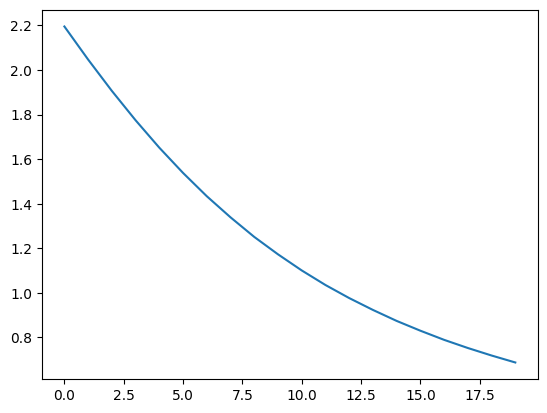

In [18]:
# plot test
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(loss)), loss)

  0%|          | 0/20 [00:00<?, ?it/s]

False


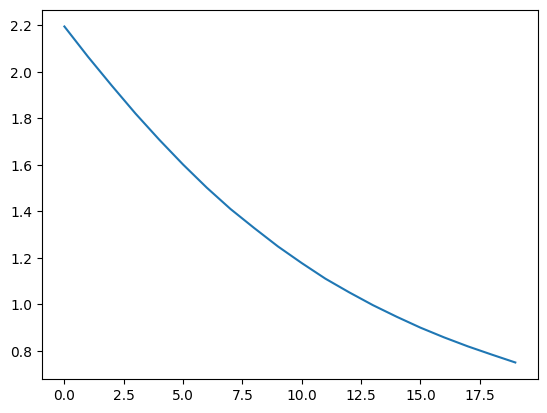

In [19]:
model = models_clean[0]
model_copy = copy.deepcopy(model)
model_copy.eval()

w_0 = (
    t.nn.utils.parameters_to_vector(model_copy.parameters()).detach().clone().to(device)
)
with t.no_grad():
    logits_init = model_copy(dataset[0])["logits"]

sgld_params = SGLDParams(eps=1e-4, gamma=0, beta=1, batch_size=1, num_steps=20)
optimizer = t.optim.SGD(model_copy.parameters(), lr=1, momentum=0, weight_decay=0)

cost_fn = "cross_entropy"

loss_2 = []
for step in tqdm(range(sgld_params.num_steps)):

    optimizer.zero_grad()

    logits = model_copy(input)["logits"]

    if cost_fn == "KL":
        cost = logit_loss(logits_init, logits)
    elif cost_fn == "cross_entropy":
        cost = t.nn.functional.cross_entropy(logits, labels)

    loss_2.append(cost.item())
    # L2 norm of w_0 - w
    w = t.nn.utils.parameters_to_vector(model_copy.parameters())

    l2_norm = t.norm(w - w_0) ** 2
    sgld_loss = (
        sgld_params.eps
        / 2
        * (
            sgld_params.nbeta * sgld_params.batch_size * cost
            + 0.5 * sgld_params.gamma * l2_norm * 0
        )
    )

    sgld_loss = sgld_loss * 2

    sgld_loss = cost * 1e-4
    # sgld_loss = cost
    sgld_loss.backward()
    optimizer.step()

    # add Gaussian noise to the model parameters
    eta = t.randn_like(w, device=device) * t.sqrt(t.tensor(sgld_params.eps))
    eta = 0 * eta
    new_params = t.nn.utils.parameters_to_vector(model_copy.parameters())
    t.nn.utils.vector_to_parameters(new_params, model_copy.parameters())


print(loss_2 == loss)
# plot test
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(loss_2)), loss_2)

In [20]:
loss

[2.1953125,
 2.046875,
 1.90625,
 1.7744140625,
 1.6513671875,
 1.5380859375,
 1.43359375,
 1.3388671875,
 1.2509765625,
 1.1728515625,
 1.1005859375,
 1.03515625,
 0.9765625,
 0.92333984375,
 0.8740234375,
 0.830078125,
 0.7890625,
 0.75244140625,
 0.71875,
 0.6875]

In [21]:
loss_2

[2.1953125,
 2.064453125,
 1.9404296875,
 1.8203125,
 1.7080078125,
 1.6015625,
 1.501953125,
 1.41015625,
 1.328125,
 1.2490234375,
 1.177734375,
 1.1103515625,
 1.0517578125,
 0.99658203125,
 0.94677734375,
 0.89990234375,
 0.85791015625,
 0.8193359375,
 0.7841796875,
 0.75]

In [22]:
model = models_clean[0]
model_copy = copy.deepcopy(model)
model_copy.eval()

optimizer = t.optim.SGD(model_copy.parameters(), lr=1e-4, momentum=0, weight_decay=0)
criterion = t.nn.CrossEntropyLoss()

losses = []
num_epochs = 20

for epoch in range(num_epochs):
    optimizer.zero_grad()

    logits = model_copy(input)["logits"]
    loss = criterion(logits, labels).to(t.float64)

    losses.append(loss.item())

    loss.backward()
    optimizer.step()

In [23]:
model = models_clean[0]
model_copy = copy.deepcopy(model)

model_copy.eval()

optimizer = t.optim.SGD(model_copy.parameters(), lr=1, momentum=0, weight_decay=0)
criterion = t.nn.CrossEntropyLoss()

losses_2 = []
num_epochs = 20

for epoch in range(num_epochs):
    optimizer.zero_grad()

    logits = model_copy(input)["logits"]
    loss = criterion(logits, labels).to(t.float64)

    losses_2.append(loss.item())
    loss = loss * 1e-4
    loss.backward()
    optimizer.step()

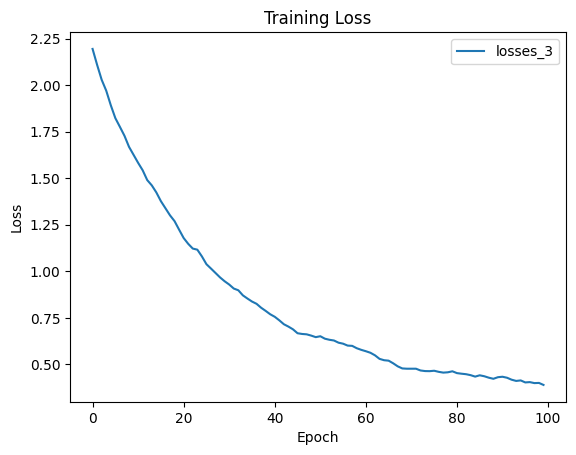

In [36]:
model = models_clean[0]
model_copy = copy.deepcopy(model)

sgld_params = SGLDParams(eps=1e-7, gamma=0, nbeta=1000, batch_size=1, num_steps=20)

model_copy.eval()

criterion = t.nn.CrossEntropyLoss()

losses_3 = []
num_epochs = 100

w_0 = (
    t.nn.utils.parameters_to_vector(model_copy.parameters()).detach().clone().to(device)
)

for _ in range(num_epochs):
    model_copy.zero_grad()

    logits = model_copy(input)["logits"]

    w = t.nn.utils.parameters_to_vector(model_copy.parameters())

    loss = criterion(logits, labels)

    losses_3.append(loss.item())

    loss.backward()

    with t.no_grad():

        w = t.nn.utils.parameters_to_vector(model_copy.parameters())

        loss_grad = -t.nn.utils.parameters_to_vector(
            [
                p.grad if p.grad is not None else t.zeros_like(p)
                for p in model_copy.parameters()
            ]
        )
        localization_grad = (w_0 - w) * sgld_params.gamma

        total_grad = (
            sgld_params.eps / 2 * (sgld_params.nbeta * loss_grad + localization_grad)
        )  # we don't need to divide by batch size because cross entropy already averages over that

        gaussian_noise = t.randn_like(w, device=device) * t.sqrt(
            t.tensor(sgld_params.eps)
        )

        w = w + total_grad + gaussian_noise
        t.nn.utils.vector_to_parameters(w, model_copy.parameters())


# Plot the training loss
import matplotlib.pyplot as plt
import numpy as np


plt.plot(np.arange(len(losses_3)), losses_3, label="losses_3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [53]:
import palamedes.sgld_sampler as palamedes

params = palamedes.SGLDParams(
    eps=1e-3, gamma=0, nbeta=10, batch_size=100, num_steps=1500
)
model = models_clean[0]

sgld_dict = palamedes.sgld(
    model,
    params,
    dataset=[clean_ds, clean_ds_labels],
    cost_fn="cross_entropy",
    device=device,
)

Cost is NaN, returning


In [54]:
sgld_dict["loss"]

[2.318359375,
 2.3359375,
 2.693359375,
 2.904296875,
 2.79296875,
 3.009765625,
 3.1796875,
 3.078125,
 3.0390625,
 2.671875,
 3.044921875,
 2.50390625,
 2.8125,
 3.470703125,
 3.72265625,
 3.017578125,
 3.091796875,
 3.974609375,
 3.568359375,
 3.943359375,
 4.4765625,
 3.869140625,
 4.328125,
 3.142578125,
 3.2109375,
 3.197265625,
 3.37109375,
 3.353515625,
 3.23828125,
 2.78515625,
 3.353515625,
 3.76953125,
 3.236328125,
 3.2890625,
 3.314453125,
 3.279296875,
 4.31640625,
 4.15625,
 3.91015625,
 3.166015625,
 3.859375,
 3.599609375,
 3.037109375,
 3.142578125,
 2.7421875,
 3.255859375,
 3.26171875,
 3.521484375,
 3.265625,
 4.1796875,
 4.375,
 3.076171875,
 3.50390625,
 3.0703125,
 3.5625,
 3.3359375,
 3.953125,
 4.8125,
 5.02734375,
 4.27734375,
 3.462890625,
 3.6015625,
 4.46484375,
 4.12890625,
 5.55859375,
 3.478515625,
 3.65625,
 3.46875,
 4.1015625,
 4.06640625,
 3.22265625,
 3.423828125,
 3.466796875,
 4.0625,
 3.994140625,
 3.638671875,
 4.0390625,
 4.15234375,
 4.191406

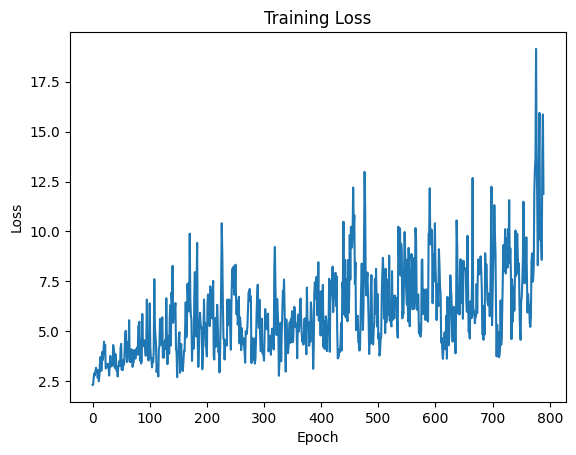

In [55]:
# plot sgld_dict["loss"]
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(sgld_dict["loss"])), sgld_dict["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

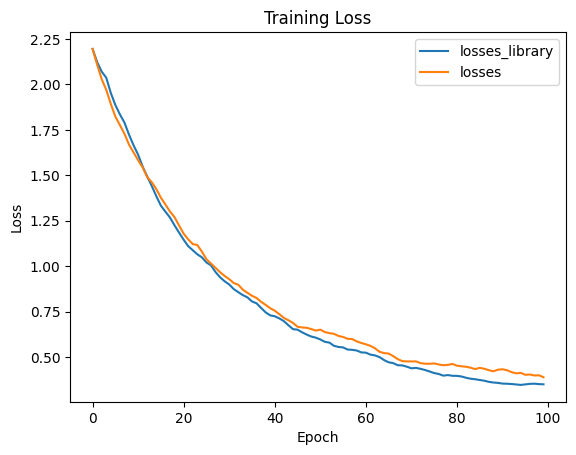

In [49]:
# plot the loss
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(sgld_dict["loss"])), sgld_dict["loss"], label="losses_library")
plt.plot(np.arange(len(losses_3)), losses_3, label="losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

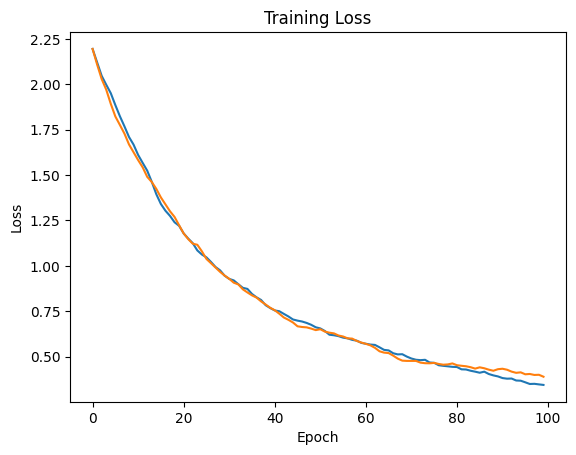

In [43]:
# plot the loss
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(sgld_dict["loss"])), sgld_dict["loss"])
plt.plot(np.arange(len(losses_3)), losses_3, label="losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [51]:
# current time as string
from datetime import datetime

now = datetime.now()
current_time = now.strftime("%Y-%m-%d %H:%M:%S")
print(f"Current time: {current_time}")
# save dict to current time
import pickle

with open(f"sgld_dict_{current_time}.pkl", "wb") as f:
    pickle.dump(sgld_dict, f)
# save losses to current time
with open(f"losses_{current_time}.pkl", "wb") as f:
    pickle.dump(losses_3, f)

Current time: 2025-02-24 15:41:03


In [10]:
dict_data = t.load(
    "/mnt/ssd-1/louis/palamedes/sgld_samples/2025-02-24_16-14-52/sgld_eps1e-06_nbeta1_batch10_steps1000/0_sgld_dict.pth",
    weights_only=False,
)

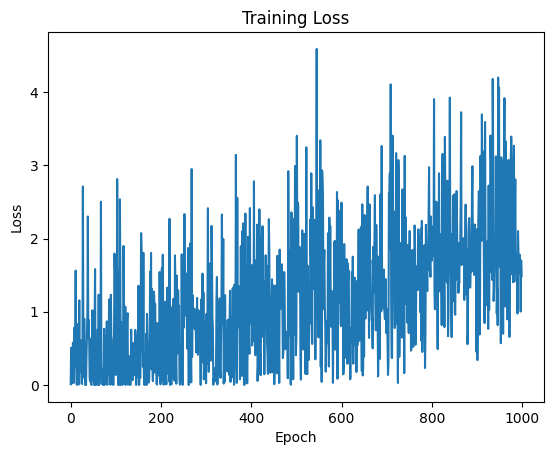

In [11]:
# plot dict_data["loss"]

import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(len(dict_data["loss"])), dict_data["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
# plot dict_data["loss"] with losses_3